# Análisis exploratorio

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

SEED = 23183 
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando device: {device}")

Usando device: cpu


In [2]:
import ssl
import certifi
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

## Cargar el dataset

In [ ]:
train_raw = MNIST(root="./data", train=True, download=True)
test_raw  = MNIST(root="./data", train=False, download=True)

100.0%
100.0%
100.0%
100.0%

Observaciones en train: 60000
Observaciones en test:  10000
Total: 70000


### ¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Las clases están balanceadas?

In [4]:
print(f"Observaciones en train: {len(train_raw)}")
print(f"Observaciones en test:  {len(test_raw)}")
print(f"Total: {len(train_raw) + len(test_raw)}")

Observaciones en train: 60000
Observaciones en test:  10000
Total: 70000


In [5]:
classes = train_raw.classes
print("Clases:", classes)
print(f"Número de clases: {len(classes)}")

Clases: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Número de clases: 10


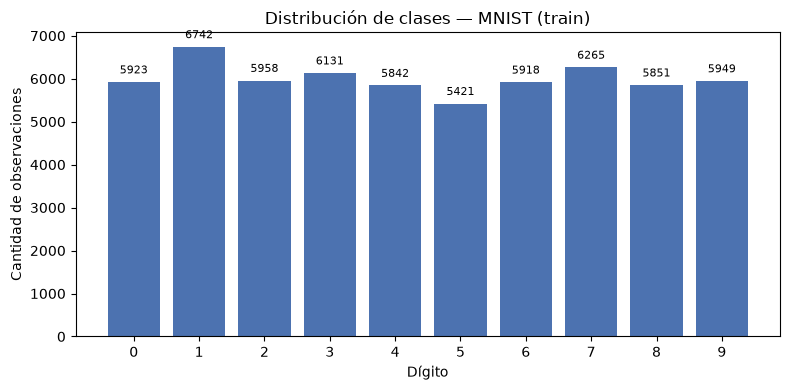

{np.int64(0): 5923, np.int64(1): 6742, np.int64(2): 5958, np.int64(3): 6131, np.int64(4): 5842, np.int64(5): 5421, np.int64(6): 5918, np.int64(7): 6265, np.int64(8): 5851, np.int64(9): 5949}

Mínimo: 5421, Máximo: 6742
Desviación relativa: 22.0%


In [6]:
labels = train_raw.targets.numpy()
counts = Counter(labels)
counts_sorted = dict(sorted(counts.items()))

plt.figure(figsize=(8, 4))
plt.bar(counts_sorted.keys(), counts_sorted.values(), color="#4C72B0")
plt.xlabel("Dígito")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de clases — MNIST (train)")
plt.xticks(range(10))
for digit, cnt in counts_sorted.items():
    plt.text(digit, cnt + 200, str(cnt), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print(counts_sorted)
print(f"\nMínimo: {min(counts_sorted.values())}, Máximo: {max(counts_sorted.values())}")
print(f"Desviación relativa: {(max(counts_sorted.values()) - min(counts_sorted.values())) / np.mean(list(counts_sorted.values())) * 100:.1f}%")

### ¿Cuál es la dimensión de cada imagen y qué rango de valores tienen los píxeles?

In [7]:
img, label = train_raw[0]
print(f"Tipo de objeto: {type(img)}")
print(f"Tamaño de la imagen (PIL): {img.size}")  # (ancho, alto)
print(f"Modo de color: {img.mode}")

img_array = np.array(img)
print(f"\nComo array de NumPy: shape = {img_array.shape}, dtype = {img_array.dtype}")
print(f"Valor mínimo de píxel: {img_array.min()}")
print(f"Valor máximo de píxel: {img_array.max()}")

Tipo de objeto: <class 'PIL.Image.Image'>
Tamaño de la imagen (PIL): (28, 28)
Modo de color: L

Como array de NumPy: shape = (28, 28), dtype = uint8
Valor mínimo de píxel: 0
Valor máximo de píxel: 255


### ¿Es necesario normalizar los valores de los píxeles?

### Visualice al menos 10 ejemplos del dataset con su etiqueta correspondiente.